# Stage 5: Grid-Year Summary

## Spatio-Temporal Analysis and Visualisation of Persistent Road Traffic Collision Hotspots

In this notebook, I will create a regular spatial grid and assign each collision
to a grid cell.

After that, I will calculate the number of collisions in each grid cell for
each year from 2020 to 2024.

The output from this stage will be used in Stage 6 for hotspot and persistence
analysis.

---



## Why I am using a spatial grid

A spatial grid divides the study area into equal-sized square cells.

Using a grid makes it possible to compare collision activity in the same
locations over different years.

I decided to use a 5 km by 5 km grid. A smaller grid such as 1 km may create
too many cells with very small yearly collision counts. A larger grid such as
10 km may hide local differences.

Therefore, 5 km provides a reasonable balance between spatial detail and
stable yearly collision counts.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Import the libraries

I am using Pandas for tables, GeoPandas for spatial data, NumPy for creating
coordinate ranges and Matplotlib for the checking maps.

In [3]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box

In [4]:
output_folder = "/content/drive/MyDrive/disseration/stage5_outputs"

os.makedirs(output_folder, exist_ok=True)

print("Stage 5 output folder:")
print(output_folder)

Stage 5 output folder:
/content/drive/MyDrive/disseration/stage5_outputs


## Load the spatial collision data

The spatial point data was already prepared during Stage 4, so I do not need
to create the point geometry again.

I will use the saved GeoPackage as the main input.

In [5]:
input_file = (
    "/content/drive/MyDrive/disseration/"
    "stage4_outputs/collision_spatial_prepared.gpkg"
)

layer_name = "collision_points"

In [6]:
collisions = gpd.read_file(
    input_file,
    layer=layer_name
)

print("Collision data loaded.")

Collision data loaded.


## Short checks before starting

The detailed checks were completed in the earlier stages. Here I am only
checking the number of records, CRS, geometry type and available columns.

In [7]:
print("Number of records:", len(collisions))
print("Number of columns:", len(collisions.columns))
print("CRS:", collisions.crs)

print("\nGeometry types:")
print(collisions.geometry.geom_type.value_counts())

print("\nMissing geometries:")
print(collisions.geometry.isna().sum())

print("\nEmpty geometries:")
print(collisions.geometry.is_empty.sum())

Number of records: 503410
Number of columns: 66
CRS: EPSG:27700

Geometry types:
Point    503410
Name: count, dtype: int64

Missing geometries:
0

Empty geometries:
0


In [8]:
if collisions.crs.to_epsg() == 27700:
    print("The data is already in EPSG:27700.")
else:
    print("The data is being converted to EPSG:27700.")
    collisions = collisions.to_crs(epsg=27700)

print("CRS being used:", collisions.crs)

The data is already in EPSG:27700.
CRS being used: EPSG:27700


## Find the year column

I do not want to assume that the column is called `accident_year` or
`collision_year`, because that could produce a KeyError.

I will first display any columns that contain the word `year`.

In [9]:
possible_year_columns = []

for column in collisions.columns:
    if "year" in column.lower():
        possible_year_columns.append(column)

print("Possible year columns:")
print(possible_year_columns)

Possible year columns:
['collision_year']


In [10]:
for column in possible_year_columns:

    print("\nColumn:", column)

    values = pd.to_numeric(
        collisions[column],
        errors="coerce"
    )

    print(
        sorted(values.dropna().unique())
    )


Column: collision_year
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [11]:
#Select the correct year column
expected_years = [2020, 2021, 2022, 2023, 2024]

year_col = None

for column in possible_year_columns:

    values = pd.to_numeric(
        collisions[column],
        errors="coerce"
    )

    years_found = sorted(
        values.dropna().astype(int).unique()
    )

    if years_found == expected_years:
        year_col = column
        break

print("Selected year column:", year_col)

Selected year column: collision_year


In [12]:
if year_col is None:
    raise ValueError(
        "The correct year column was not found. "
        "Please check the possible year columns shown above."
    )

In [13]:
#Create a simple year column
collisions["year"] = pd.to_numeric(
    collisions[year_col],
    errors="coerce"
)

print("Missing year values:", collisions["year"].isna().sum())

Missing year values: 0


In [14]:
#Convert the year to integer
collisions["year"] = collisions["year"].astype(int)

print("Years in the dataset:")
print(sorted(collisions["year"].unique()))

print("\nCollision records by year:")
print(
    collisions["year"]
    .value_counts()
    .sort_index()
)

Years in the dataset:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Collision records by year:
year
2020     91185
2021    101070
2022    105982
2023    104246
2024    100927
Name: count, dtype: int64


## Check the total spatial bounds

The bounds show the minimum and maximum British National Grid eastings and
northings.

I will use these coordinates to create the square grid.

In [15]:
min_x, min_y, max_x, max_y = collisions.total_bounds

print("Minimum easting:", min_x)
print("Minimum northing:", min_y)
print("Maximum easting:", max_x)
print("Maximum northing:", max_y)

Minimum easting: 65948.85625325324
Minimum northing: 10210.465296540613
Maximum easting: 655344.9957949881
Maximum northing: 1184352.528357004


## Set the grid size

The British National Grid uses metres, so a grid size of 5,000 means that each
cell will be 5 km wide and 5 km high.

Each grid cell will cover 25 square kilometres.

Advantages of the 5 km grid:

- It provides more local detail than a 10 km grid.
- It should produce more stable yearly counts than a 1 km grid.
- It keeps the dataset manageable for Google Colab.
- It creates consistent areas for comparing different years.

Disadvantages:

- Some grid cells may contain several roads or settlements.
- Collisions close to each other may be separated by a grid boundary.
- Different grid sizes may produce different results.
- The rectangular grid may include offshore or unused areas.

In [16]:
#Set the grid size
grid_size = 5000

print("Grid size:", grid_size, "metres")

print(
    "Grid cell area:",
    (grid_size * grid_size) / 1_000_000,
    "square kilometres"
)

Grid size: 5000 metres
Grid cell area: 25.0 square kilometres


## Round the bounds

I am rounding the minimum coordinates down and the maximum coordinates up.

This helps make sure that the grid covers all the collision points.

In [17]:
grid_min_x = np.floor(min_x / grid_size) * grid_size
grid_min_y = np.floor(min_y / grid_size) * grid_size

grid_max_x = np.ceil(max_x / grid_size) * grid_size
grid_max_y = np.ceil(max_y / grid_size) * grid_size

print("Rounded grid bounds:")

print(
    grid_min_x,
    grid_min_y,
    grid_max_x,
    grid_max_y
)

Rounded grid bounds:
65000.0 10000.0 660000.0 1185000.0


## Create the square grid

I will create the grid one row at a time using the rounded British National
Grid coordinates.

In [18]:
#Create coordinate ranges
x_coordinates = np.arange(
    grid_min_x,
    grid_max_x,
    grid_size
)

y_coordinates = np.arange(
    grid_min_y,
    grid_max_y,
    grid_size
)

print("Number of grid columns:", len(x_coordinates))
print("Number of grid rows:", len(y_coordinates))

Number of grid columns: 119
Number of grid rows: 235


In [19]:
#Create grid polygons
grid_polygons = []
grid_rows = []
grid_columns = []

for row_number, y in enumerate(y_coordinates):

    for column_number, x in enumerate(x_coordinates):

        polygon = box(
            x,
            y,
            x + grid_size,
            y + grid_size
        )

        grid_polygons.append(polygon)
        grid_rows.append(row_number)
        grid_columns.append(column_number)

In [20]:
#Convert the grid into a GeoDataFrame
grid = gpd.GeoDataFrame(
    {
        "grid_row": grid_rows,
        "grid_col": grid_columns
    },
    geometry=grid_polygons,
    crs="EPSG:27700"
)

print("Number of grid cells:", len(grid))
print("Grid CRS:", grid.crs)

grid.head()

Number of grid cells: 27965
Grid CRS: EPSG:27700


,grid_row,grid_col,geometry
0,0,0,"POLYGON ((70000 10000, 70000 15000, 65000 1500..."
1,0,1,"POLYGON ((75000 10000, 75000 15000, 70000 1500..."
2,0,2,"POLYGON ((80000 10000, 80000 15000, 75000 1500..."
3,0,3,"POLYGON ((85000 10000, 85000 15000, 80000 1500..."
4,0,4,"POLYGON ((90000 10000, 90000 15000, 85000 1500..."


## Give every grid cell a unique ID

The grid ID is created using the row and column number.

This should make it easier to identify the same cell in later stages.

In [21]:
grid["grid_id"] = (
    "R"
    + grid["grid_row"].astype(str).str.zfill(3)
    + "_C"
    + grid["grid_col"].astype(str).str.zfill(3)
)

grid["cell_size_m"] = grid_size

grid["cell_area_km2"] = (
    grid.geometry.area / 1_000_000
)

grid["centroid_easting"] = grid.geometry.centroid.x
grid["centroid_northing"] = grid.geometry.centroid.y

grid.head()

,grid_row,grid_col,geometry,grid_id,cell_size_m,cell_area_km2,centroid_easting,centroid_northing
0,0,0,"POLYGON ((70000 10000, 70000 15000, 65000 1500...",R000_C000,5000,25.0,67500.0,12500.0
1,0,1,"POLYGON ((75000 10000, 75000 15000, 70000 1500...",R000_C001,5000,25.0,72500.0,12500.0
2,0,2,"POLYGON ((80000 10000, 80000 15000, 75000 1500...",R000_C002,5000,25.0,77500.0,12500.0
3,0,3,"POLYGON ((85000 10000, 85000 15000, 80000 1500...",R000_C003,5000,25.0,82500.0,12500.0
4,0,4,"POLYGON ((90000 10000, 90000 15000, 85000 1500...",R000_C004,5000,25.0,87500.0,12500.0


In [22]:
print("Number of grid cells:", len(grid))

print(
    "Number of unique grid IDs:",
    grid["grid_id"].nunique()
)

print(
    "Duplicate grid IDs:",
    grid["grid_id"].duplicated().sum()
)

Number of grid cells: 27965
Number of unique grid IDs: 27965
Duplicate grid IDs: 0


## Create a checking map

I will plot the grid with a sample of collision points.

I am only using a sample for this map because plotting all 503,000 points may
make the map slow and difficult to read.

In [23]:
sample_size = min(10000, len(collisions))

collision_sample = collisions.sample(
    n=sample_size,
    random_state=42
)

print("Points used in checking map:", len(collision_sample))

Points used in checking map: 10000


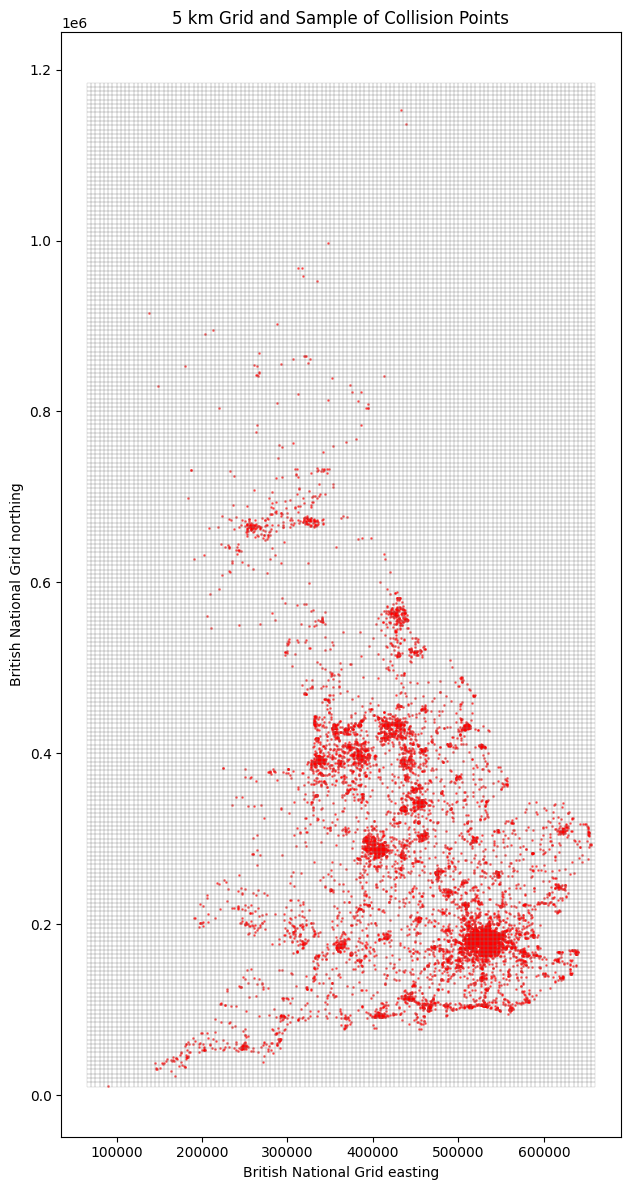

In [24]:
fig, ax = plt.subplots(figsize=(10, 12))

grid.boundary.plot(
    ax=ax,
    linewidth=0.15,
    color="grey"
)

collision_sample.plot(
    ax=ax,
    markersize=1,
    color="red",
    alpha=0.5
)

ax.set_title("5 km Grid and Sample of Collision Points")

ax.set_xlabel("British National Grid easting")
ax.set_ylabel("British National Grid northing")

plt.tight_layout()

grid_map_file = os.path.join(
    output_folder,
    "grid_and_collision_check.png"
)

plt.savefig(
    grid_map_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Assign collisions to grid cells

I will use a spatial join to add the grid ID to each collision.

I am using `intersects` because it should also include points that fall exactly
on the edge of a grid cell.

In [25]:
collisions = collisions.reset_index(drop=True)

collisions["collision_row_id"] = collisions.index

print("Collision records:", len(collisions))

Collision records: 503410


In [26]:
#Select the grid columns needed for the join
grid_for_join = grid[
    [
        "grid_id",
        "grid_row",
        "grid_col",
        "geometry"
    ]
].copy()

In [27]:
#Carry out the spatial join
collision_grid = gpd.sjoin(
    collisions,
    grid_for_join,
    how="left",
    predicate="intersects"
)

print("Rows after spatial join:", len(collision_grid))

Rows after spatial join: 503410


## Check for points matching more than one cell

A point exactly on a grid boundary may intersect two cells.

If this happens, I will keep one grid assignment so that the collision is not
counted twice.

In [28]:
#Check duplicate collision assignments
duplicate_assignments = (
    collision_grid["collision_row_id"]
    .duplicated()
    .sum()
)

print(
    "Extra rows caused by boundary matches:",
    duplicate_assignments
)

Extra rows caused by boundary matches: 0


In [29]:
#Keep one grid cell for each collision
collision_grid = collision_grid.sort_values(
    ["collision_row_id", "grid_id"]
)

collision_grid = collision_grid.drop_duplicates(
    subset="collision_row_id",
    keep="first"
)

collision_grid = collision_grid.reset_index(drop=True)

print("Rows after removing duplicate assignments:", len(collision_grid))

Rows after removing duplicate assignments: 503410


In [30]:
#Check unassigned collisions
unassigned_points = collision_grid["grid_id"].isna().sum()

print(
    "Collision points not assigned to a grid:",
    unassigned_points
)

if unassigned_points == 0:
    print("All collision points were assigned to a grid cell.")
else:
    print("Some collision points need further checking.")

Collision points not assigned to a grid: 0
All collision points were assigned to a grid cell.


In [31]:
#Confirm that the record count has not changed
print("Original collision records:", len(collisions))
print("Collision records after join:", len(collision_grid))

if len(collisions) == len(collision_grid):
    print("The number of collision records is correct.")
else:
    print("The number of records has changed and needs checking.")

Original collision records: 503410
Collision records after join: 503410
The number of collision records is correct.


## Find the collision severity column

As with the year variable, I will search the actual column names rather than
assuming the severity column name.

In [32]:
#Display possible severity column
possible_severity_columns = []

for column in collision_grid.columns:

    if (
        "severity" in column.lower()
        and "score" not in column.lower()
    ):
        possible_severity_columns.append(column)

print("Possible severity columns:")
print(possible_severity_columns)

Possible severity columns:
['collision_severity', 'enhanced_severity_collision', 'collision_adjusted_severity_serious', 'collision_adjusted_severity_slight', 'severity_label']


In [33]:
#Check severity values
for column in possible_severity_columns:

    print("\nColumn:", column)

    print(
        collision_grid[column]
        .value_counts(dropna=False)
        .head(10)
    )


Column: collision_severity
collision_severity
3    385960
2    109960
1      7490
Name: count, dtype: int64

Column: enhanced_severity_collision
enhanced_severity_collision
-1    241260
 3    190370
 7     40703
 6     15029
 5     11429
 1      4619
Name: count, dtype: int64

Column: collision_adjusted_severity_serious
collision_adjusted_severity_serious
0.000000    290357
1.000000    109958
0.025511         2
0.101028         2
0.053760         2
0.209280         2
0.082918         2
0.034092         2
0.038524         2
0.161247         2
Name: count, dtype: int64

Column: collision_adjusted_severity_slight
collision_adjusted_severity_slight
1.000000    282867
0.000000    117448
0.974489         2
0.898972         2
0.946240         2
0.790720         2
0.917082         2
0.965908         2
0.961476         2
0.838753         2
Name: count, dtype: int64

Column: severity_label
severity_label
Slight     385960
Serious    109960
Fatal        7490
Name: count, dtype: int64


In [34]:
#Choose a severity column
severity_col = None

preferred_severity_names = [
    "collision_severity",
    "accident_severity",
    "severity"
]

for preferred_name in preferred_severity_names:

    if preferred_name in collision_grid.columns:
        severity_col = preferred_name
        break

if severity_col is None and len(possible_severity_columns) > 0:
    severity_col = possible_severity_columns[0]

print("Selected severity column:", severity_col)

Selected severity column: collision_severity


## Standardise the severity values

The source data may contain text labels or numeric codes.

The common numeric collision severity codes are:

- 1 = Fatal
- 2 = Serious
- 3 = Slight

I will convert both text and numeric values into the same three categories.

In [35]:
#Create a standard severity category
if severity_col is not None:

    collision_grid["severity_group"] = (
        collision_grid[severity_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    severity_number = pd.to_numeric(
        collision_grid[severity_col],
        errors="coerce"
    )

    collision_grid.loc[
        severity_number == 1,
        "severity_group"
    ] = "fatal"

    collision_grid.loc[
        severity_number == 2,
        "severity_group"
    ] = "serious"

    collision_grid.loc[
        severity_number == 3,
        "severity_group"
    ] = "slight"

    collision_grid.loc[
        collision_grid["severity_group"].str.contains(
            "fatal",
            na=False
        ),
        "severity_group"
    ] = "fatal"

    collision_grid.loc[
        collision_grid["severity_group"].str.contains(
            "serious",
            na=False
        ),
        "severity_group"
    ] = "serious"

    collision_grid.loc[
        collision_grid["severity_group"].str.contains(
            "slight",
            na=False
        ),
        "severity_group"
    ] = "slight"

    print(
        collision_grid["severity_group"]
        .value_counts(dropna=False)
    )

severity_group
slight     385960
serious    109960
fatal        7490
Name: count, dtype: int64


In [36]:
#Check whether severity is available
severity_available = False

if severity_col is not None:

    valid_severity = collision_grid[
        "severity_group"
    ].isin(
        ["fatal", "serious", "slight"]
    )

    if valid_severity.sum() > 0:
        severity_available = True

print("Severity data available:", severity_available)

Severity data available: True


## Create severity count variables

I will create separate variables for fatal, serious and slight collisions.

I will also create a simple severity score:

- Fatal = 3
- Serious = 2
- Slight = 1

This is an analytical score created for this project. It is not an official
DfT severity score.

In [37]:
#Create severity indicators and score
if severity_available:

    collision_grid["fatal_collision"] = (
        collision_grid["severity_group"] == "fatal"
    ).astype(int)

    collision_grid["serious_collision"] = (
        collision_grid["severity_group"] == "serious"
    ).astype(int)

    collision_grid["slight_collision"] = (
        collision_grid["severity_group"] == "slight"
    ).astype(int)

    score_map = {
        "fatal": 3,
        "serious": 2,
        "slight": 1
    }

    collision_grid["severity_score"] = (
        collision_grid["severity_group"]
        .map(score_map)
    )

    collision_grid[
        [
            "severity_group",
            "fatal_collision",
            "serious_collision",
            "slight_collision",
            "severity_score"
        ]
    ].head()

## Aggregate collisions by grid ID and year

Each row in the summary will represent one grid cell in one year.

The main variable will be the number of collisions in that grid-year.

In [38]:
#Create the basic collision count
grid_year_count = (
    collision_grid
    .groupby(
        ["grid_id", "year"]
    )
    .size()
    .reset_index(
        name="collision_count"
    )
)

grid_year_count.head()

,grid_id,year,collision_count
0,R000_C005,2022,2
1,R000_C005,2023,3
2,R000_C005,2024,2
3,R000_C021,2020,1
4,R000_C021,2021,1


In [39]:
#Add severity measures where available
if severity_available:

    grid_year_severity = (
        collision_grid
        .groupby(
            ["grid_id", "year"]
        )
        .agg(
            fatal_count=(
                "fatal_collision",
                "sum"
            ),
            serious_count=(
                "serious_collision",
                "sum"
            ),
            slight_count=(
                "slight_collision",
                "sum"
            ),
            total_severity_score=(
                "severity_score",
                "sum"
            ),
            mean_severity_score=(
                "severity_score",
                "mean"
            )
        )
        .reset_index()
    )

    grid_year_observed = grid_year_count.merge(
        grid_year_severity,
        on=["grid_id", "year"],
        how="left"
    )

else:

    grid_year_observed = grid_year_count.copy()

In [40]:
print("Observed grid-year rows:", len(grid_year_observed))

grid_year_observed.head(10)

Observed grid-year rows: 30380


,grid_id,year,collision_count,fatal_count,serious_count,slight_count,total_severity_score,mean_severity_score
0,R000_C005,2022,2,0,0,2,2,1.000000
1,R000_C005,2023,3,0,1,2,4,1.333333
2,R000_C005,2024,2,0,2,0,4,2.000000
3,R000_C021,2020,1,0,0,1,1,1.000000
4,R000_C021,2021,1,0,1,0,2,2.000000
5,R000_C021,2023,2,0,1,1,3,1.500000
6,R001_C020,2020,2,0,0,2,2,1.000000
7,R001_C020,2021,4,0,2,2,6,1.500000
8,R001_C020,2022,2,0,0,2,2,1.000000
9,R001_C020,2023,4,0,1,3,5,1.250000


## Identify grid cells used during the study period

The full rectangular grid contains offshore cells and cells that did not
contain any collision between 2020 and 2024.

For the main analysis, I will keep grid cells that recorded at least one
collision during the complete five-year period.

These cells can still have zero collisions in individual years.

In [41]:
#Create the analysis grid
used_grid_ids = (
    collision_grid["grid_id"]
    .dropna()
    .unique()
)

analysis_grid = grid[
    grid["grid_id"].isin(used_grid_ids)
].copy()

print("Total cells in full grid:", len(grid))

print(
    "Cells containing at least one collision:",
    len(analysis_grid)
)

print(
    "Cells with no collisions in all five years:",
    len(grid) - len(analysis_grid)
)

Total cells in full grid: 27965
Cells containing at least one collision: 7606
Cells with no collisions in all five years: 20359


## Create all grid-year combinations

The observed summary only contains years where a collision occurred.

For persistence analysis, I need every selected grid cell to appear in every
year. This means that a cell with zero collisions in a particular year must
still have a row for that year.

In [42]:
grid_year_index = pd.MultiIndex.from_product(
    [
        analysis_grid["grid_id"],
        expected_years
    ],
    names=[
        "grid_id",
        "year"
    ]
)

all_grid_years = (
    grid_year_index
    .to_frame(index=False)
)

print("Expected grid-year rows:")
print(len(analysis_grid) * len(expected_years))

print("Created grid-year rows:")
print(len(all_grid_years))

Expected grid-year rows:
38030
Created grid-year rows:
38030


In [43]:
grid_year = all_grid_years.merge(
    grid_year_observed,
    on=["grid_id", "year"],
    how="left"
)

grid_year.head(10)

,grid_id,year,collision_count,fatal_count,serious_count,slight_count,total_severity_score,mean_severity_score
0,R000_C005,2020,NaN,NaN,NaN,NaN,NaN,NaN
1,R000_C005,2021,NaN,NaN,NaN,NaN,NaN,NaN
2,R000_C005,2022,2.0,0.0,0.0,2.0,2.0,1.000000
3,R000_C005,2023,3.0,0.0,1.0,2.0,4.0,1.333333
4,R000_C005,2024,2.0,0.0,2.0,0.0,4.0,2.000000
5,R000_C021,2020,1.0,0.0,0.0,1.0,1.0,1.000000
6,R000_C021,2021,1.0,0.0,1.0,0.0,2.0,2.000000
7,R000_C021,2022,NaN,NaN,NaN,NaN,NaN,NaN
8,R000_C021,2023,2.0,0.0,1.0,1.0,3.0,1.500000
9,R000_C021,2024,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
#Replace missing counts with zero
count_columns = [
    "collision_count"
]

if severity_available:

    count_columns = count_columns + [
        "fatal_count",
        "serious_count",
        "slight_count",
        "total_severity_score"
    ]

for column in count_columns:

    grid_year[column] = (
        grid_year[column]
        .fillna(0)
    )

In [45]:
#Convert count variables to integers
integer_columns = [
    "collision_count"
]

if severity_available:

    integer_columns = integer_columns + [
        "fatal_count",
        "serious_count",
        "slight_count"
    ]

for column in integer_columns:

    grid_year[column] = (
        grid_year[column]
        .astype(int)
    )

In [46]:
#Add simple grid-year status variables
grid_year["occupied_in_year"] = (
    grid_year["collision_count"] > 0
).astype(int)

grid_year["zero_collision_year"] = (
    grid_year["collision_count"] == 0
).astype(int)

print(
    "Zero-collision grid-year rows:",
    grid_year["zero_collision_year"].sum()
)

grid_year.head(10)

Zero-collision grid-year rows: 7650


,grid_id,year,collision_count,fatal_count,serious_count,slight_count,total_severity_score,mean_severity_score,occupied_in_year,zero_collision_year
0,R000_C005,2020,0,0,0,0,0.0,NaN,0,1
1,R000_C005,2021,0,0,0,0,0.0,NaN,0,1
2,R000_C005,2022,2,0,0,2,2.0,1.000000,1,0
3,R000_C005,2023,3,0,1,2,4.0,1.333333,1,0
4,R000_C005,2024,2,0,2,0,4.0,2.000000,1,0
5,R000_C021,2020,1,0,0,1,1.0,1.000000,1,0
6,R000_C021,2021,1,0,1,0,2.0,2.000000,1,0
7,R000_C021,2022,0,0,0,0,0.0,NaN,0,1
8,R000_C021,2023,2,0,1,1,3.0,1.500000,1,0
9,R000_C021,2024,0,0,0,0,0.0,NaN,0,1


## Why zero-collision rows are important

A missing row and a zero collision count have different meanings.

A missing row could suggest that the cell was not included in the study. A
zero row shows that the cell was included but had no reported collision during
that year.

These rows will help later when identifying:

- cells active in every year;
- intermittent collision locations;
- cells becoming more active;
- cells becoming less active;
- emerging locations;
- non-hotspot years for predictive modelling.

## Join the summary back to the grid geometry

The grid polygon will appear once for every year.

This creates a spatial dataset that can be mapped and used in Stage 6.

In [47]:
grid_attributes = analysis_grid[
    [
        "grid_id",
        "grid_row",
        "grid_col",
        "cell_size_m",
        "cell_area_km2",
        "centroid_easting",
        "centroid_northing",
        "geometry"
    ]
].copy()

In [48]:
#Join geometry to the grid-year table
grid_year_spatial = grid_year.merge(
    grid_attributes,
    on="grid_id",
    how="left"
)

grid_year_spatial = gpd.GeoDataFrame(
    grid_year_spatial,
    geometry="geometry",
    crs="EPSG:27700"
)

grid_year_spatial = grid_year_spatial.sort_values(
    ["grid_id", "year"]
).reset_index(drop=True)

print("Grid-year records:", len(grid_year_spatial))
print("Grid-year CRS:", grid_year_spatial.crs)

grid_year_spatial.head()

Grid-year records: 38030
Grid-year CRS: EPSG:27700


,grid_id,year,collision_count,fatal_count,serious_count,slight_count,total_severity_score,mean_severity_score,occupied_in_year,zero_collision_year,grid_row,grid_col,cell_size_m,cell_area_km2,centroid_easting,centroid_northing,geometry
0,R000_C005,2020,0,0,0,0,0.0,NaN,0,1,0,5,5000,25.0,92500.0,12500.0,"POLYGON ((95000 10000, 95000 15000, 90000 1500..."
1,R000_C005,2021,0,0,0,0,0.0,NaN,0,1,0,5,5000,25.0,92500.0,12500.0,"POLYGON ((95000 10000, 95000 15000, 90000 1500..."
2,R000_C005,2022,2,0,0,2,2.0,1.000000,1,0,0,5,5000,25.0,92500.0,12500.0,"POLYGON ((95000 10000, 95000 15000, 90000 1500..."
3,R000_C005,2023,3,0,1,2,4.0,1.333333,1,0,0,5,5000,25.0,92500.0,12500.0,"POLYGON ((95000 10000, 95000 15000, 90000 1500..."
4,R000_C005,2024,2,0,2,0,4.0,2.000000,1,0,0,5,5000,25.0,92500.0,12500.0,"POLYGON ((95000 10000, 95000 15000, 90000 1500..."


## Create yearly summary information

This table will show the total collision count, number of occupied grid cells,
number of zero-collision cells and maximum number of collisions in one cell
for each year.

In [49]:
#Create the yearly summary
yearly_summary_list = []

for year in expected_years:

    year_data = grid_year[
        grid_year["year"] == year
    ]

    occupied_data = year_data[
        year_data["collision_count"] > 0
    ]

    summary_row = {
        "year": year,
        "total_collisions": year_data[
            "collision_count"
        ].sum(),
        "occupied_grid_cells": len(occupied_data),
        "zero_collision_grid_cells": (
            year_data["collision_count"] == 0
        ).sum(),
        "mean_collisions_per_occupied_cell": (
            occupied_data["collision_count"].mean()
        ),
        "maximum_collisions_in_one_grid_cell": (
            year_data["collision_count"].max()
        )
    }

    if severity_available:

        summary_row["fatal_collisions"] = (
            year_data["fatal_count"].sum()
        )

        summary_row["serious_collisions"] = (
            year_data["serious_count"].sum()
        )

        summary_row["slight_collisions"] = (
            year_data["slight_count"].sum()
        )

    yearly_summary_list.append(summary_row)

yearly_summary = pd.DataFrame(yearly_summary_list)

yearly_summary[
    "mean_collisions_per_occupied_cell"
] = yearly_summary[
    "mean_collisions_per_occupied_cell"
].round(2)

yearly_summary

,year,total_collisions,occupied_grid_cells,zero_collision_grid_cells,mean_collisions_per_occupied_cell,maximum_collisions_in_one_grid_cell,fatal_collisions,serious_collisions,slight_collisions
0,2020,91185,5947,1659,15.33,1182,1391,18353,71441
1,2021,101070,6068,1538,16.66,1495,1473,21279,78318
2,2022,105982,6093,1513,17.39,1497,1602,23327,81053
3,2023,104246,6135,1471,16.99,1409,1522,23434,79290
4,2024,100927,6137,1469,16.45,1344,1502,23567,75858


In [50]:
#Create an overall grid summary
overall_summary = pd.DataFrame({
    "measure": [
        "Grid size in metres",
        "Grid cell area in square kilometres",
        "Full rectangular grid cells",
        "Analysis grid cells",
        "Cells with no collisions across all years",
        "Analysis grid-year rows",
        "Zero-collision grid-year rows",
        "Total collision records"
    ],
    "value": [
        grid_size,
        (grid_size * grid_size) / 1_000_000,
        len(grid),
        len(analysis_grid),
        len(grid) - len(analysis_grid),
        len(grid_year),
        (
            grid_year["collision_count"] == 0
        ).sum(),
        len(collisions)
    ]
})

overall_summary

,measure,value
0,Grid size in metres,5000.0
1,Grid cell area in square kilometres,25.0
2,Full rectangular grid cells,27965.0
3,Analysis grid cells,7606.0
4,Cells with no collisions across all years,20359.0
5,Analysis grid-year rows,38030.0
6,Zero-collision grid-year rows,7650.0
7,Total collision records,503410.0


## Validate the yearly collision totals

The total number of collisions in the grid-year dataset should match the
original number of collisions for every year.

If the difference is zero, the spatial join and aggregation have worked
correctly.

In [51]:
original_yearly_totals = (
    collisions
    .groupby("year")
    .size()
    .reset_index(
        name="original_total"
    )
)

original_yearly_totals

,year,original_total
0,2020,91185
1,2021,101070
2,2022,105982
3,2023,104246
4,2024,100927


In [52]:
aggregated_yearly_totals = (
    grid_year
    .groupby("year")["collision_count"]
    .sum()
    .reset_index(
        name="aggregated_total"
    )
)

aggregated_yearly_totals

,year,aggregated_total
0,2020,91185
1,2021,101070
2,2022,105982
3,2023,104246
4,2024,100927


In [53]:
#Compare the totals
validation_table = original_yearly_totals.merge(
    aggregated_yearly_totals,
    on="year"
)

validation_table["difference"] = (
    validation_table["aggregated_total"]
    - validation_table["original_total"]
)

validation_table["totals_match"] = (
    validation_table["difference"] == 0
)

validation_table

,year,original_total,aggregated_total,difference,totals_match
0,2020,91185,91185,0,True
1,2021,101070,101070,0,True
2,2022,105982,105982,0,True
3,2023,104246,104246,0,True
4,2024,100927,100927,0,True


In [54]:
if validation_table["totals_match"].all():
    print("Validation passed. All yearly totals match.")
else:
    print("Validation failed. Some yearly totals do not match.")

Validation passed. All yearly totals match.


## Create collision-count checking maps

I will create maps for 2020 and 2024.

These are only checking maps showing collision counts. They are not hotspot
maps.

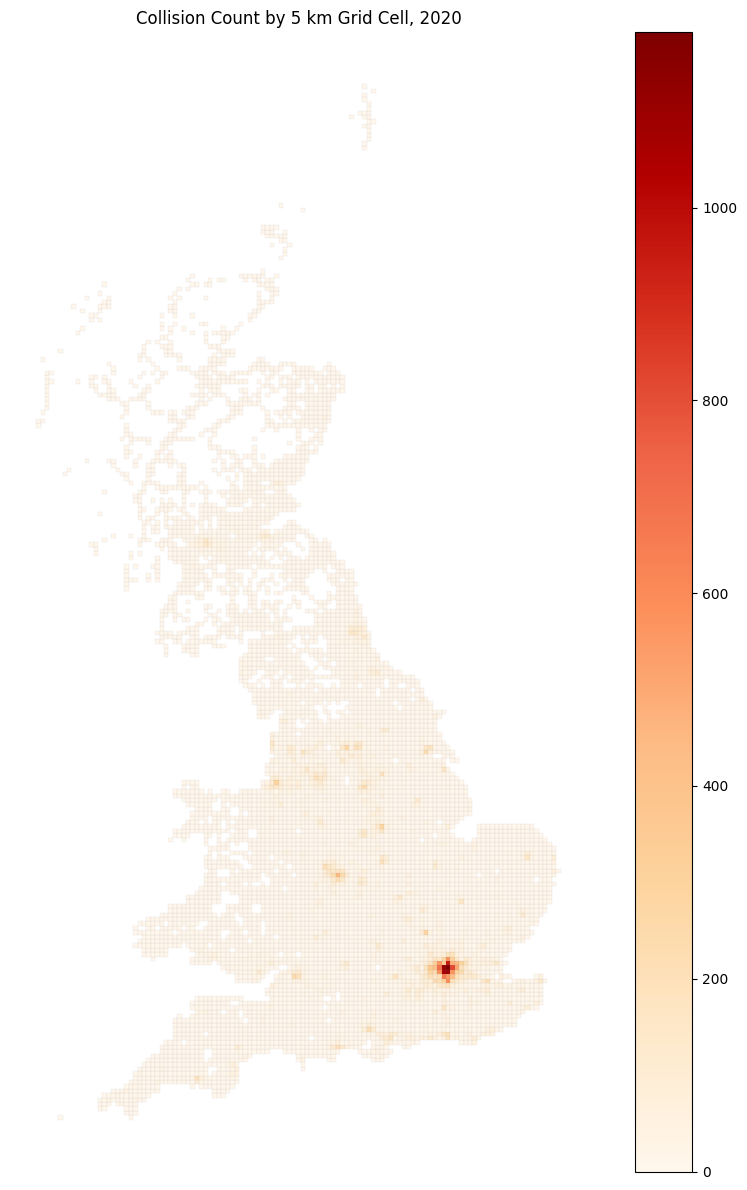

In [55]:
#Map collision counts for 2020
map_2020 = grid_year_spatial[
    grid_year_spatial["year"] == 2020
].copy()

fig, ax = plt.subplots(figsize=(10, 12))

map_2020.plot(
    column="collision_count",
    cmap="OrRd",
    linewidth=0.05,
    edgecolor="grey",
    legend=True,
    ax=ax
)

ax.set_title(
    "Collision Count by 5 km Grid Cell, 2020"
)

ax.set_axis_off()

plt.tight_layout()

map_2020_file = os.path.join(
    output_folder,
    "collision_count_2020.png"
)

plt.savefig(
    map_2020_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

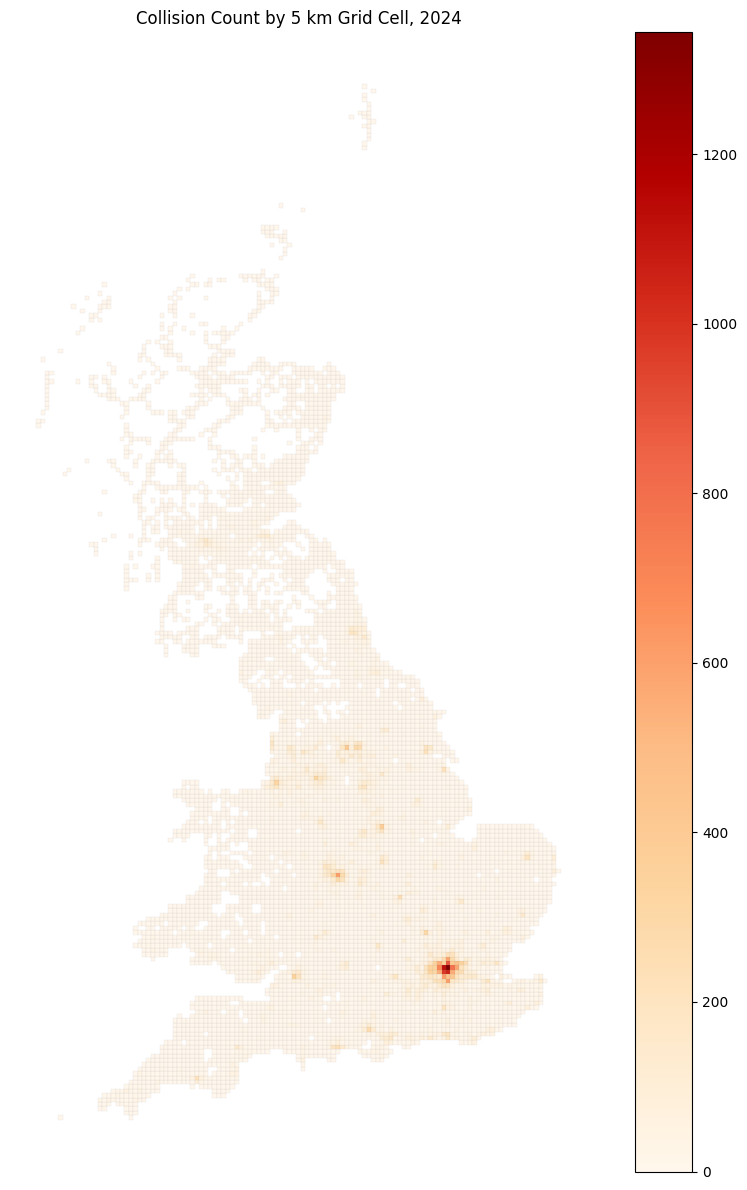

In [56]:
#Map collision counts for 2024
map_2024 = grid_year_spatial[
    grid_year_spatial["year"] == 2024
].copy()

fig, ax = plt.subplots(figsize=(10, 12))

map_2024.plot(
    column="collision_count",
    cmap="OrRd",
    linewidth=0.05,
    edgecolor="grey",
    legend=True,
    ax=ax
)

ax.set_title(
    "Collision Count by 5 km Grid Cell, 2024"
)

ax.set_axis_off()

plt.tight_layout()

map_2024_file = os.path.join(
    output_folder,
    "collision_count_2024.png"
)

plt.savefig(
    map_2024_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Save the Stage 5 outputs

I will save:

- the full rectangular grid;
- the analysis grid;
- the spatial grid-year dataset;
- a CSV version for later modelling and Power BI;
- the summary tables;
- the validation table.

In [57]:
full_grid_file = os.path.join(
    output_folder,
    "grid_5km_full_extent.gpkg"
)

analysis_grid_file = os.path.join(
    output_folder,
    "grid_5km_analysis.gpkg"
)

grid_year_file = os.path.join(
    output_folder,
    "grid_year_5km_analysis.gpkg"
)

grid_year_csv_file = os.path.join(
    output_folder,
    "grid_year_5km_analysis.csv"
)

yearly_summary_file = os.path.join(
    output_folder,
    "stage5_yearly_summary.csv"
)

overall_summary_file = os.path.join(
    output_folder,
    "stage5_overall_summary.csv"
)

validation_file = os.path.join(
    output_folder,
    "stage5_validation.csv"
)

In [58]:
geopackage_files = [
    full_grid_file,
    analysis_grid_file,
    grid_year_file
]

for file in geopackage_files:

    if os.path.exists(file):
        os.remove(file)
        print("Removed old file:", file)

In [59]:
grid.to_file(
    full_grid_file,
    layer="grid_5km_full_extent",
    driver="GPKG",
    index=False
)

analysis_grid.to_file(
    analysis_grid_file,
    layer="grid_5km_analysis",
    driver="GPKG",
    index=False
)

print("Grid files saved.")

Grid files saved.


In [60]:
grid_year_spatial.to_file(
    grid_year_file,
    layer="grid_year_analysis",
    driver="GPKG",
    index=False
)

print("Spatial grid-year dataset saved.")

Spatial grid-year dataset saved.


In [61]:
grid_year_non_spatial = (
    grid_year_spatial
    .drop(columns="geometry")
    .copy()
)

grid_year_non_spatial.to_csv(
    grid_year_csv_file,
    index=False
)

print("Non-spatial grid-year CSV saved.")

Non-spatial grid-year CSV saved.


In [62]:
yearly_summary.to_csv(
    yearly_summary_file,
    index=False
)

overall_summary.to_csv(
    overall_summary_file,
    index=False
)

validation_table.to_csv(
    validation_file,
    index=False
)

print("Stage 5 summary tables saved.")

Stage 5 summary tables saved.


In [63]:
print("Stage 5 output files:\n")

for file_name in sorted(os.listdir(output_folder)):
    print(file_name)

Stage 5 output files:

collision_count_2020.png
collision_count_2024.png
grid_5km_analysis.gpkg
grid_5km_full_extent.gpkg
grid_and_collision_check.png
grid_year_5km_analysis.csv
grid_year_5km_analysis.gpkg
stage5_overall_summary.csv
stage5_validation.csv
stage5_yearly_summary.csv


# Stage 5 Summary

In this notebook, I created a regular 5 km by 5 km spatial grid using British
National Grid coordinates.

Each grid cell was given a unique grid ID. I then assigned every collision
point to a grid cell using a spatial join.

The collision records were aggregated by grid ID and year. This produced the
yearly collision count for each cell. Where severity information was
available, fatal, serious and slight collision counts were also calculated.

A simple severity score was created where fatal collisions received a score of
3, serious collisions received a score of 2 and slight collisions received a
score of 1.

I created a complete grid-year dataset for 2020 to 2024. Grid cells containing
collisions during the five-year study period were included for every year,
including years where the collision count was zero.

The zero-collision records are important because they show that the location
was part of the analysis but did not record a collision during that particular
year.

The yearly aggregated collision totals were compared with the original
collision totals. This validation was used to confirm that collisions were not
lost or counted twice during the spatial join.

The grid geometry, spatial grid-year dataset, non-spatial CSV, checking maps
and summary tables were saved in the Stage 5 output folder.

The grid-year dataset is now ready for Stage 6, where hotspot and persistence
measures will be calculated.

In [ ]:
s